# Polynomial Regression — Projectile Position Prediction

Predict the **y** position of a projectile from noisy **x** measurements using OLS polynomial regression (degree 2 and 20) and Lasso regression.

## 0. Import

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
import pandas as pd
np.random.seed(42)

## 1. Data Generation

In [2]:
def dataSimulate():
    x0, y0 = 0, 2
    theta0_rad = np.deg2rad(50)
    v0, g = 10, 9.81
    dt = 0.01

    # --- Calcul analytique du temps d'impact au sol ---
    # y(t) = 0  =>  (g/2)*t² - v0*sin(θ)*t - y0 = 0
    a = 0.5 * g
    b = -v0 * np.sin(theta0_rad)
    c = -y0
    delta = b**2 - 4*a*c
    t_sol = (-b + np.sqrt(delta)) / (2*a)  # racine positive

    # --- Données d'entraînement : de t=0 jusqu'à t_sol ---
    t_train = np.arange(0, t_sol, dt)
    xr_train = x0 + v0 * np.cos(theta0_rad) * t_train
    yr_train = y0 + v0 * np.sin(theta0_rad) * t_train - 0.5 * g * t_train**2

    x_noisy = xr_train + np.random.normal(0, 0.5, size=xr_train.shape)
    y_noisy = yr_train + np.random.normal(0, 0.5, size=yr_train.shape)

    # --- Données d'extrapolation : 30% au-delà du sol ---
    t_extrap = np.arange(0, 1.3 * t_sol, dt)
    xr_extrap = x0 + v0 * np.cos(theta0_rad) * t_extrap
    yr_extrap = y0 + v0 * np.sin(theta0_rad) * t_extrap - 0.5 * g * t_extrap**2

    x_extrap_noisy = xr_extrap + np.random.normal(0, 0.5, size=xr_extrap.shape)
    y_extrap_noisy = yr_extrap + np.random.normal(0, 0.5, size=yr_extrap.shape)

    # Portée exacte (position x au moment de l'impact)
    x_sol = x0 + v0 * np.cos(theta0_rad) * t_sol

    return x_noisy, y_noisy, x_extrap_noisy, y_extrap_noisy, x_sol


x_noisy, y_noisy, x_extrap, y_extrap_true, x_theorique_limite = dataSimulate()
print(f"Training points     : {len(x_noisy)}")
print(f"Extrapolation points: {len(x_extrap)}")
print(f"Frontière théorique : {x_theorique_limite:.4f}")


Training points     : 179
Extrapolation points: 233
Frontière théorique : 11.5034


## 2. Train/Test Split (80% train, 20% test)

In [3]:
def splitData(x_noisy, y_noisy):
    X_train, X_test, y_train, y_test = train_test_split(x_noisy, y_noisy, test_size=0.2, random_state=42)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = splitData(x_noisy, y_noisy)


## 3. Functions

In [4]:
def matriceA(X_train, X_test, degree):
    poly = PolynomialFeatures(degree)
    A_train = poly.fit_transform(X_train.reshape(-1, 1))
    A_test  = poly.transform(X_test.reshape(-1, 1))
    return A_train, A_test

def scaleFunction(A_train, A_test, y_train, y_test):
    scaler_A = StandardScaler()
    A_train_scaled = scaler_A.fit_transform(A_train)
    A_test_scaled  = scaler_A.transform(A_test)

    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_test_scaled  = scaler_y.transform(y_test.reshape(-1, 1)).flatten()
    return A_train_scaled, A_test_scaled, y_train_scaled, y_test_scaled

def OlspreditY(A_train_scaled, A_test_scaled, y_train_scaled):
    OLS_reg = LinearRegression().fit(A_train_scaled, y_train_scaled)
    y_Pred_OLS = OLS_reg.predict(A_test_scaled)
    return y_Pred_OLS

def lassoPreditY(A_train_scaled, A_test_scaled, y_train_scaled, alpha):
    lasso_reg = Lasso(alpha=alpha, max_iter=100000).fit(A_train_scaled, y_train_scaled)
    y_Pred_Lasso = lasso_reg.predict(A_test_scaled)
    return y_Pred_Lasso

def lassoCvPreditY(A_train_scaled, A_test_scaled, y_train_scaled, cv):
    lassoCV_reg = LassoCV(cv=cv, max_iter=100000, random_state=42).fit(A_train_scaled, y_train_scaled)
    y_Pred_LassoCV = lassoCV_reg.predict(A_test_scaled)
    return y_Pred_LassoCV, lassoCV_reg.alpha_

def ridgePreditY(A_train_scaled, A_test_scaled, y_train_scaled, alpha):
    ridge_reg = Ridge(alpha=alpha).fit(A_train_scaled, y_train_scaled)
    y_Pred_Ridge = ridge_reg.predict(A_test_scaled)
    return y_Pred_Ridge

def ridgeCvPreditY(A_train_scaled, A_test_scaled, y_train_scaled, alphas, cv):
    ridge_reg = RidgeCV(alphas=alphas, cv=cv).fit(A_train_scaled, y_train_scaled)
    y_Pred_Ridge = ridge_reg.predict(A_test_scaled)
    return y_Pred_Ridge, ridge_reg.alpha_

## 4. OLS Regression — Polynomial Degree 2

In [5]:
A_train, A_test = matriceA(X_train, X_test, degree=2)
A_train_sc, A_test_sc, y_train_sc, y_test_sc = scaleFunction(A_train, A_test, y_train, y_test)
y_pred_2 = OlspreditY(A_train_sc, A_test_sc, y_train_sc)
r2_2   = r2_score(y_test_sc, y_pred_2)
rmse_2 = root_mean_squared_error(y_test_sc, y_pred_2)
print(f"OLS Degree 2  — R2: {r2_2:.4f}  | RMSE: {rmse_2:.4f}")

OLS Degree 2  — R2: 0.7266  | RMSE: 0.4165


## 5. OLS Regression — Polynomial Degree 20

In [6]:
A_train_20, A_test_20 = matriceA(X_train, X_test, degree=20)
A_train_sc_20, A_test_sc_20, y_train_sc_20, y_test_sc_20 = scaleFunction(A_train_20, A_test_20, y_train, y_test)
y_pred_20 = OlspreditY(A_train_sc_20, A_test_sc_20, y_train_sc_20)
r2_20   = r2_score(y_test_sc_20, y_pred_20)
rmse_20 = root_mean_squared_error(y_test_sc_20, y_pred_20)
print(f"OLS Degree 20 — R2: {r2_20:.4f}  | RMSE: {rmse_20:.4f}")

OLS Degree 20 — R2: 0.6815  | RMSE: 0.4496


## OLS Degré 2 vs OLS Degré 20
OLS avec 2 degrés est bien meilleur qu'OLS degré 20 en raison de l'overfitting. C'est-à-dire que le modèle avec 20 degrés épouse tellement les données d'entraînement, et donc aussi le bruit de celles-ci, ce qui le conduit à être moins performant pour prédire avec les variables test.
Ce qui confirme que la trajectoire physique est bien une parabole. Un modèle simple et adapté à la 
physique du problème surpasse largement un modèle trop complexe.


## 6. Lasso Regression — Polynomial Degree 20

Same degree-20 polynomial features and scaling as above. We test different values of alpha to observe the regularization effect.

In [7]:
for alpha in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
    y_pred_lasso_20  = lassoPreditY(A_train_sc_20, A_test_sc_20, y_train_sc_20, alpha)
    r2_lasso_20      = r2_score(y_test_sc_20, y_pred_lasso_20)
    rmse_lasso_20    = root_mean_squared_error(y_test_sc_20, y_pred_lasso_20)
    print(f"Lasso Degree 20 (alpha={alpha}) — R2: {r2_lasso_20:.4f}  | RMSE: {rmse_lasso_20:.4f}")

Lasso Degree 20 (alpha=0.001) — R2: 0.7344  | RMSE: 0.4106
Lasso Degree 20 (alpha=0.01) — R2: 0.7446  | RMSE: 0.4026
Lasso Degree 20 (alpha=0.1) — R2: 0.5010  | RMSE: 0.5627
Lasso Degree 20 (alpha=1.0) — R2: -0.0731  | RMSE: 0.8253
Lasso Degree 20 (alpha=10.0) — R2: -0.0731  | RMSE: 0.8253
Lasso Degree 20 (alpha=100.0) — R2: -0.0731  | RMSE: 0.8253


## 8.Lasso Regression Cross-Validation 

In [15]:
y_pred_lassoCV_20, best_alpha_lasso = lassoCvPreditY(A_train_sc_20, A_test_sc_20, y_train_sc_20, cv=5)
r2_lassoCV_20   = r2_score(y_test_sc_20, y_pred_lassoCV_20)
rmse_lassoCV_20 = root_mean_squared_error(y_test_sc_20, y_pred_lassoCV_20)
print(f"LassoCV Degree 20 — Best alpha: {best_alpha_lasso:.6f}")
print(f"LassoCV Degree 20 — R2: {r2_lassoCV_20:.4f}  | RMSE: {rmse_lassoCV_20:.4f}")

LassoCV Degree 20 — Best alpha: 0.000781
LassoCV Degree 20 — R2: 0.7335  | RMSE: 0.4112


## Comparaison Lasso vs LassoCV


Pour la régression Lasso de degré 20, plusieurs valeurs de α ont été testées manuellement.  
Le meilleur résultat manuel est obtenu avec α = 0.01, avec R² = 0.7446 et RMSE = 0.4026.

Avec LassoCV, la valeur de α est choisie automatiquement par cross-validation. Pour cv = 5, LassoCV sélectionne α = 0.000781 et donne R² = 0.7335 et RMSE = 0.4112.Pour un cv plus grand le resultat est moins mais reste constant.
Le modèle manuel avec α = 0.01 est donc légèrement meilleur sur les test, car il donne un R² un peu plus élevé et un RMSE un peu plus faible. 
Mais le alpha de LassoCV est plus robuste car il a été trouve par la methode cross validation 
  

## 9. Ridge Regression

In [17]:
for alpha in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
    y_pred_ridge_20 = ridgePreditY(A_train_sc_20, A_test_sc_20, y_train_sc_20, alpha)
    r2_ridge_20     = r2_score(y_test_sc_20, y_pred_ridge_20)
    rmse_ridge_20   = root_mean_squared_error(y_test_sc_20, y_pred_ridge_20)
    print(f"Ridge Degree 20 (alpha={alpha}) — R2: {r2_ridge_20:.4f}  | RMSE: {rmse_ridge_20:.4f}")

Ridge Degree 20 (alpha=0.001) — R2: 0.7246  | RMSE: 0.4181
Ridge Degree 20 (alpha=0.01) — R2: 0.7270  | RMSE: 0.4162
Ridge Degree 20 (alpha=0.1) — R2: 0.7301  | RMSE: 0.4139
Ridge Degree 20 (alpha=1.0) — R2: 0.7470  | RMSE: 0.4007
Ridge Degree 20 (alpha=10.0) — R2: 0.7181  | RMSE: 0.4230
Ridge Degree 20 (alpha=100.0) — R2: 0.5410  | RMSE: 0.5397


## 10. Ridge Regression Cross-Validation

In [16]:
alphas = np.logspace(-4, 2, 100)
y_pred_RidgeCV_20, best_alpha_ridge = ridgeCvPreditY(A_train_sc_20, A_test_sc_20, y_train_sc_20, alphas, cv=5)
r2_RidgeCV_20   = r2_score(y_test_sc_20, y_pred_RidgeCV_20)
rmse_RidgeCV_20 = root_mean_squared_error(y_test_sc_20, y_pred_RidgeCV_20)
print(f"RidgeCV Degree 20 — Best alpha: {best_alpha_ridge:.6f}")
print(f"RidgeCV Degree 20 — R2: {r2_RidgeCV_20:.4f}  | RMSE: {rmse_RidgeCV_20:.4f}")

RidgeCV Degree 20 — Best alpha: 0.020092
RidgeCV Degree 20 — R2: 0.7269  | RMSE: 0.4163


## Ridge vs RidgeCV
A nouveau RidgeCV est moins performant tans au niveau resultat qu au niveau temps.
Mais comme pour LassoCV,les alpha trouvé avec la methode cross valiation pour Ridge est plus robuste.
## Ridge vs OLS
Le résultat est plus contrasté : Ridge que ce soit manuellement ou par cross validation on de meilleur resultat que OLS.
OLS a deux degré se defend bient dantis que  OLS degré 20 est loin derirer. Nous pouvons conclure que Ridge arrive à limiter le bruit malgré les grands degrés et être plus performant qu'OLS.

## Ridge vs Lasso
Ridge reste inférieur à Lasso ici, probablement parce que Ridge ne peut pas annuler complètement les coefficients les moins utiles. Il les réduit seulement, alors que Lasso peut les ramener exactement à zéro. Dans un modèle de degré 20, cela permet à Lasso de mieux limiter l'effet des termes trop sensibles au bruit.
On aurai pu croire initialment que Ridge allais l emporte car comem dit au tp il est adapté si :You expect many features to have small but nonzero contributions and want to reduce sensitivity to noise mais le fait qu on  soit de degre 20 cela implifie le bruit et rend certaine donné irrelevant ce qui compense son l avantage au profit de lasso 
A noter que si on joue sur les cv on peux arriver a linverse,que Ridge soit meilleur que Lasso cela demontre le fait que la diference entre les deux est minime danc notre cas.

## Comparaison des 4 modèles sur la zone d'entraînement

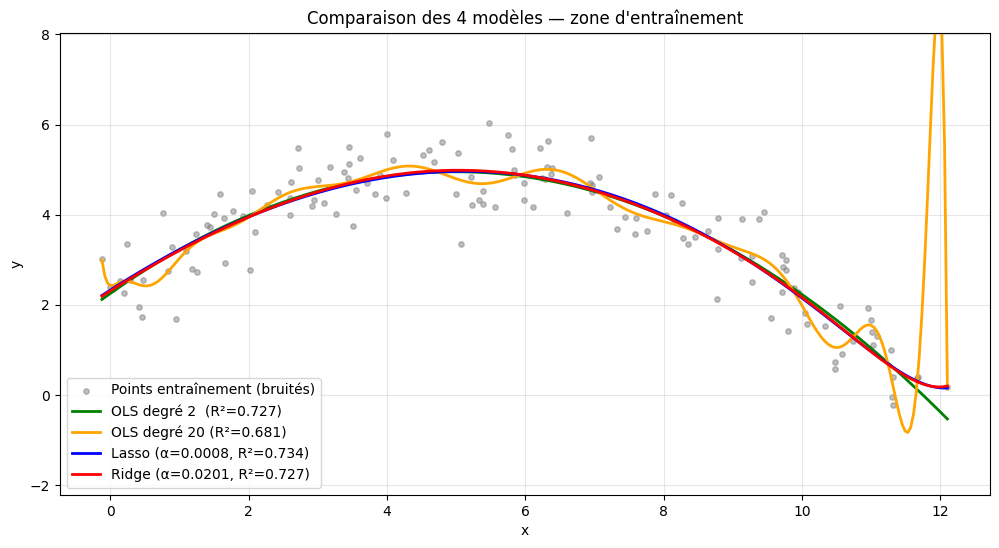

In [11]:
x_grid = np.linspace(X_train.min(), X_train.max(), 300).reshape(-1, 1)

sc_y = StandardScaler()
y_tr_sc = sc_y.fit_transform(y_train.reshape(-1, 1)).flatten()

# Degré 2
poly2 = PolynomialFeatures(2)
A_tr2 = poly2.fit_transform(X_train.reshape(-1, 1))
A_gr2 = poly2.transform(x_grid)
sc_A2 = StandardScaler()
A_tr2_sc = sc_A2.fit_transform(A_tr2)
A_gr2_sc = sc_A2.transform(A_gr2)
g_ols2 = sc_y.inverse_transform(
    LinearRegression().fit(A_tr2_sc, y_tr_sc).predict(A_gr2_sc).reshape(-1, 1)
).flatten()

# Degré 20
poly20 = PolynomialFeatures(20)
A_tr20 = poly20.fit_transform(X_train.reshape(-1, 1))
A_gr20 = poly20.transform(x_grid)
sc_A20 = StandardScaler()
A_tr20_sc = sc_A20.fit_transform(A_tr20)
A_gr20_sc = sc_A20.transform(A_gr20)
g_ols20 = sc_y.inverse_transform(
    LinearRegression().fit(A_tr20_sc, y_tr_sc).predict(A_gr20_sc).reshape(-1, 1)
).flatten()
g_lasso = sc_y.inverse_transform(
    Lasso(alpha=best_alpha_lasso, max_iter=100000).fit(A_tr20_sc, y_tr_sc).predict(A_gr20_sc).reshape(-1, 1)
).flatten()
g_ridge = sc_y.inverse_transform(
    Ridge(alpha=best_alpha_ridge).fit(A_tr20_sc, y_tr_sc).predict(A_gr20_sc).reshape(-1, 1)
).flatten()

plt.figure(figsize=(12, 6))
plt.scatter(X_train, y_train, s=15, color='gray', alpha=0.5, label='Points entraînement (bruités)')
plt.plot(x_grid, g_ols2,  color='green',  lw=2, label=f'OLS degré 2  (R²={r2_2:.3f})')
plt.plot(x_grid, g_ols20, color='orange', lw=2, label=f'OLS degré 20 (R²={r2_20:.3f})')
plt.plot(x_grid, g_lasso, color='blue',   lw=2, label=f'Lasso (α={best_alpha_lasso:.4f}, R²={r2_lassoCV_20:.3f})')
plt.plot(x_grid, g_ridge, color='red',    lw=2, label=f'Ridge (α={best_alpha_ridge:.4f}, R²={r2_RidgeCV_20:.3f})')
plt.ylim(y_train.min() - 2, y_train.max() + 2)
plt.xlabel('x')
plt.ylabel('y')
plt.title("Comparaison des 4 modèles — zone d'entraînement")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:

rmse_2     = root_mean_squared_error(y_test_sc,    y_pred_2)
rmse_20    = root_mean_squared_error(y_test_sc_20, y_pred_20)
rmse_lasso = root_mean_squared_error(y_test_sc_20, y_pred_lassoCV_20)
rmse_ridge = root_mean_squared_error(y_test_sc_20, y_pred_RidgeCV_20)

summary = pd.DataFrame({
    'Modèle': [
        'OLS degré 2',
        'OLS degré 20',
        f'Lasso CV (α={best_alpha_lasso:.4f})',
        f'Ridge CV (α={best_alpha_ridge:.4f})'
    ],
    'R²':   [r2_2, r2_20, r2_lassoCV_20, r2_RidgeCV_20],
    'RMSE': [rmse_2, rmse_20, rmse_lasso, rmse_ridge]
}).round(4)

print("── Comparaison des 4 modèles (test set) ──")
print(summary.to_string(index=False))

── Comparaison des 4 modèles (test set) ──
             Modèle     R²   RMSE
        OLS degré 2 0.7266 0.4165
       OLS degré 20 0.6815 0.4496
Lasso CV (α=0.0008) 0.7335 0.4112
Ridge CV (α=0.0201) 0.7269 0.4163


## Conclusion
Lasso donne les meilleurs résultats de R² et RMSE, RIDGE OLS degre 2 et OLS degre 20 complette le podium.

Ridge viens apres lasso.Cela s explique car Lasso peut annuler certains coefficients bruités, tandis que Ridge les réduit seulement. 
Le modèle OLS degré 2 est déjà bien adapté, avec un bon R² et RMSE, car la trajectoire d'un projectile est naturellement quadratique. 
Au contraire, OLS degré 20 est trop complexe et surapprend davantage le bruit.
Les méthodes Lasso et Ridge améliorent donc le modèle de degré 20 grâce à la régularisation. 
Les versions CV permettent de choisir automatiquement α. Le score R² ou RMSE obtenu n'est pas toujours le meilleur, mais le résultat est plus robuste : α est sélectionné en testant plusieurs découpages train/test des données, ce qui réduit le risque de tomber sur un α optimal uniquement par chance sur un découpage particulier.

## 11. Lasso vs Ridge — Extrapolation (x étendu)

Lasso (α=0.0015) — R²: -20.4876  | RMSE: 10.2443
Ridge (α=0.0006) — R²: -421.9306  | RMSE: 45.4491

Lasso :  7/21 coefficients non nuls
Ridge : 20/21 coefficients non nuls


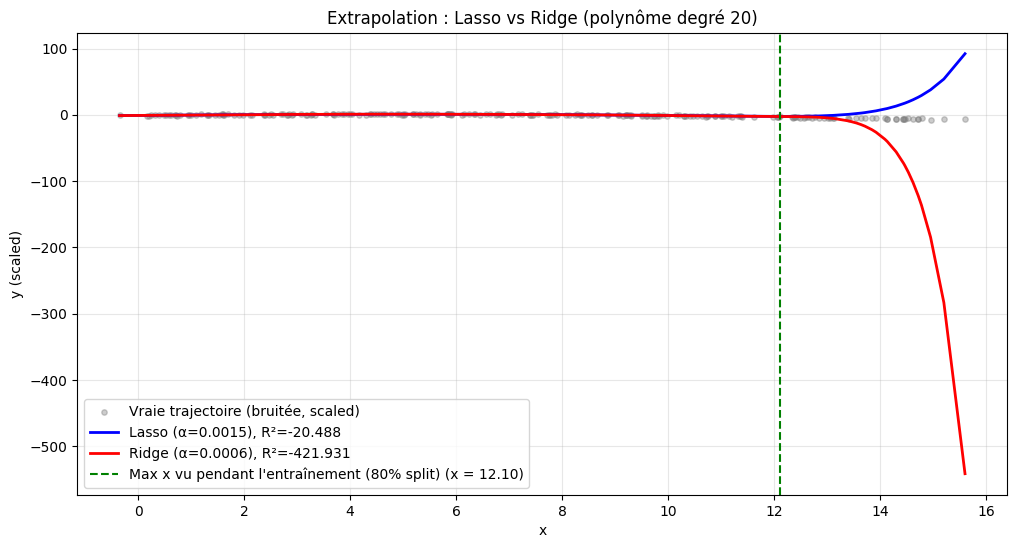

In [13]:

best_alpha_lasso = 0.001504
best_alpha_ridge = 0.000556
A_train_extr, A_extrap = matriceA(X_train, x_extrap, degree=20)
A_train_extr_sc, A_extrap_sc, y_train_extr_sc, y_extrap_sc = scaleFunction(
    A_train_extr, A_extrap, y_train, y_extrap_true
)
y_extrap_lasso = lassoPreditY(A_train_extr_sc, A_extrap_sc, y_train_extr_sc, alpha=best_alpha_lasso)
y_extrap_ridge = ridgePreditY(A_train_extr_sc, A_extrap_sc, y_train_extr_sc, alpha=best_alpha_ridge)

# 4. Métriques en extrapolation
r2_lasso_extr  = r2_score(y_extrap_sc, y_extrap_lasso)
r2_ridge_extr  = r2_score(y_extrap_sc, y_extrap_ridge)
rmse_lasso     = root_mean_squared_error(y_extrap_sc, y_extrap_lasso)
rmse_ridge     = root_mean_squared_error(y_extrap_sc, y_extrap_ridge)

print(f"Lasso (α={best_alpha_lasso:.4f}) — R²: {r2_lasso_extr:.4f}  | RMSE: {rmse_lasso:.4f}")
print(f"Ridge (α={best_alpha_ridge:.4f}) — R²: {r2_ridge_extr:.4f}  | RMSE: {rmse_ridge:.4f}")

# 5. Comptage des coefficients actifs 
lasso_model = Lasso(alpha=best_alpha_lasso, max_iter=100000).fit(A_train_extr_sc, y_train_extr_sc)
ridge_model = Ridge(alpha=best_alpha_ridge).fit(A_train_extr_sc, y_train_extr_sc)
print(f"\nLasso : {np.sum(lasso_model.coef_ != 0):>2}/21 coefficients non nuls")
print(f"Ridge : {np.sum(np.abs(ridge_model.coef_) > 1e-6):>2}/21 coefficients non nuls")

# 6. Graphique
idx = np.argsort(x_extrap)
x_sorted        = x_extrap[idx]
y_true_sorted   = y_extrap_sc[idx]
y_lasso_sorted  = y_extrap_lasso[idx]
y_ridge_sorted  = y_extrap_ridge[idx]

x_train_max = X_train.max()

plt.figure(figsize=(12, 6))
plt.scatter(x_sorted, y_true_sorted, s=15, color='gray', alpha=0.4,
            label='Vraie trajectoire (bruitée, scaled)')
plt.plot(x_sorted, y_lasso_sorted, color='blue', lw=2,
         label=f'Lasso (α={best_alpha_lasso:.4f}), R²={r2_lasso_extr:.3f}')
plt.plot(x_sorted, y_ridge_sorted, color='red', lw=2,
         label=f'Ridge (α={best_alpha_ridge:.4f}), R²={r2_ridge_extr:.3f}')
plt.axvline(x_train_max, color='green', ls='--',
            label=f'Max x vu pendant l\'entraînement (80% split) (x = {x_train_max:.2f})')
plt.xlabel('x')
plt.ylabel('y (scaled)')
plt.title('Extrapolation : Lasso vs Ridge (polynôme degré 20)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

TEST

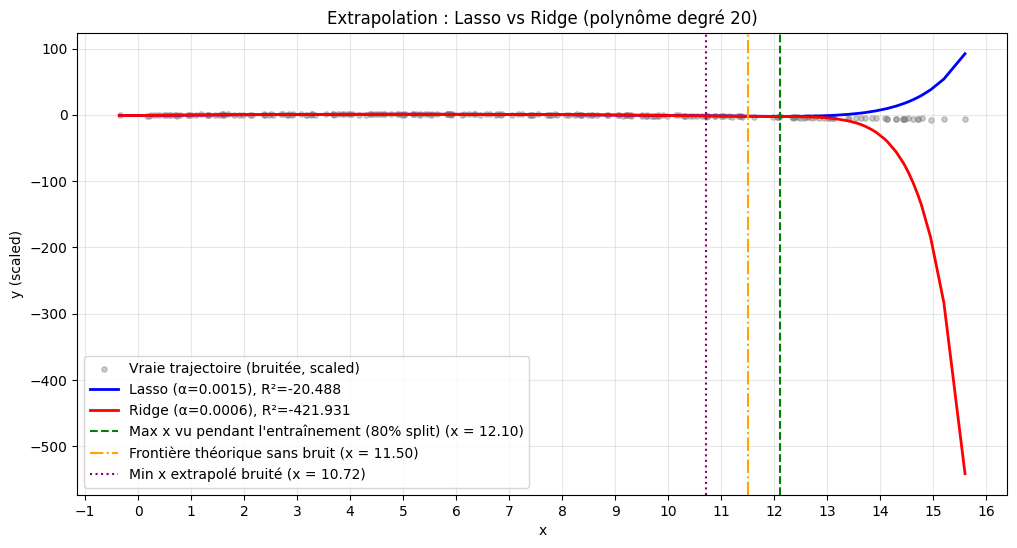

In [14]:
# 6. Graphique
idx = np.argsort(x_extrap)
x_sorted        = x_extrap[idx]
y_true_sorted   = y_extrap_sc[idx]
y_lasso_sorted  = y_extrap_lasso[idx]
y_ridge_sorted  = y_extrap_ridge[idx]

x_train_max = X_train.max()

x_extrap_only_min = x_extrap[len(x_noisy):].min()

plt.figure(figsize=(12, 6))
plt.scatter(x_sorted, y_true_sorted, s=15, color='gray', alpha=0.4,
            label='Vraie trajectoire (bruitée, scaled)')
plt.plot(x_sorted, y_lasso_sorted, color='blue', lw=2,
         label=f'Lasso (α={best_alpha_lasso:.4f}), R²={r2_lasso_extr:.3f}')
plt.plot(x_sorted, y_ridge_sorted, color='red', lw=2,
         label=f'Ridge (α={best_alpha_ridge:.4f}), R²={r2_ridge_extr:.3f}')

plt.axvline(x_train_max, color='green', ls='--',
            label=f'Max x vu pendant l\'entraînement (80% split) (x = {x_train_max:.2f})')
plt.axvline(x_theorique_limite, color='orange', ls='-.',
            label=f'Frontière théorique sans bruit (x = {x_theorique_limite:.2f})')
plt.axvline(x_extrap_only_min, color='purple', ls=':',
            label=f'Min x extrapolé bruité (x = {x_extrap_only_min:.2f})')

plt.xticks(np.arange(np.floor(x_sorted.min()), np.ceil(x_sorted.max()) + 1, 1))
plt.xlabel('x')
plt.ylabel('y (scaled)')
plt.title('Extrapolation : Lasso vs Ridge (polynôme degré 20)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Discussion — Point 11
Bien que les deux modèles soient mauvais en extrapolation (R²<0), 
Lasso reste nettement moins mauvais que Ridge, avec un R²=-32.6 contre 
R²=-7592.6 et un RMSE de 12.9 contre 193.9

**Lasso** : met la plupart des coefficients à zéro, donc le modèle se réduit aux 4 premiers termes, c'est-à-dire à un polynôme de degré 3 — la divergence est limitée hors de la plage d'entraînement.

**Ridge** : garde tous les coefficients actifs, ce qui conduit à ce que la somme des termes x², x³...x²⁰ explose dès qu'on sort de la zone d'entraînement. Remarque : on voit qu'il y a un coefficient nul dans Ridge, ce qui en théorie est impossible, mais comme il est si petit, Python a dû le considérer comme nul.